In [9]:
import pandas as pd
import numpy as np

data_train=pd.read_csv('T-R-train.csv')

In [11]:
x_train=data_train.loc[:,'temperature']
y_train=data_train.loc[:,'rate']

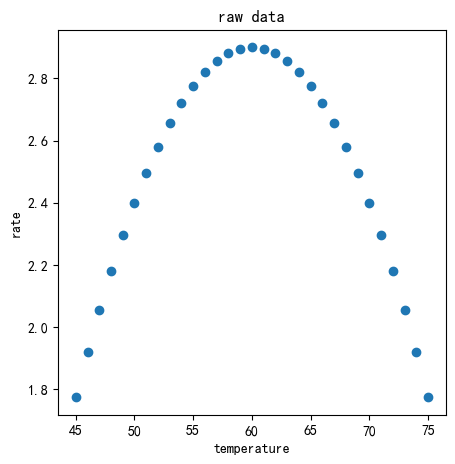

In [12]:
%matplotlib inline
from matplotlib import pyplot as plt
fig1=plt.figure(figsize=(5,5))
plt.scatter(x_train,y_train)
plt.title('raw data')
plt.xlabel('temperature')
plt.ylabel('rate')
plt.show()

In [22]:
x_train=np.array(x_train).reshape(-1,1)

In [23]:
from sklearn.linear_model import LinearRegression
lr1=LinearRegression()
lr1.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
data_test=pd.read_csv('T-R-test.csv')
x_test=data_test.loc[:,'temperature']
y_test=data_test.loc[:,'rate']
x_test=np.array(x_test).reshape(-1,1)

In [29]:
y_train_predict=lr1.predict(x_train)
y_test_predict=lr1.predict(x_test)
from sklearn.metrics import r2_score
r2_train=r2_score(y_train,y_train_predict)
r2_test=r2_score(y_test,y_test_predict)
print(' r2_train',r2_train,'\n','r2_test',r2_test)

 r2_train 0.0 
 r2_test -0.34556730330364416


In [34]:
#生成连续数据
x_range=np.linspace(40,90,300).reshape(-1,1)
y_range_predict=lr1.predict(x_range)

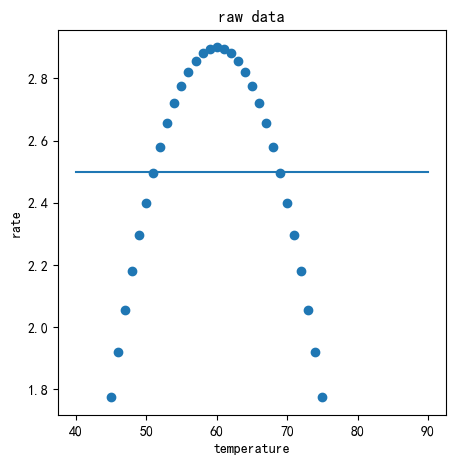

In [36]:
fig2=plt.figure(figsize=(5,5))
plt.plot(x_range,y_range_predict)
plt.scatter(x_train,y_train)
plt.title('raw data')
plt.xlabel('temperature')
plt.ylabel('rate')
plt.show()

In [40]:
#多项式模型
from sklearn.preprocessing import PolynomialFeatures
poly2=PolynomialFeatures(degree=2)
x_2_train=poly2.fit_transform(x_train)
x_2_test=poly2.transform(x_test)

In [45]:
lr2=LinearRegression()
lr2.fit(x_2_train,y_train)

y_2_train_predict=lr2.predict(x_2_train)
y_2_test_predict=lr2.predict(x_2_test)
r2_2_train=r2_score(y_train,y_2_train_predict)
r2_2_test=r2_score(y_test,y_2_test_predict)
print(' r2_2_train',r2_2_train,'\n','r2_2_test',r2_2_test)

 r2_2_train 1.0 
 r2_2_test 1.0


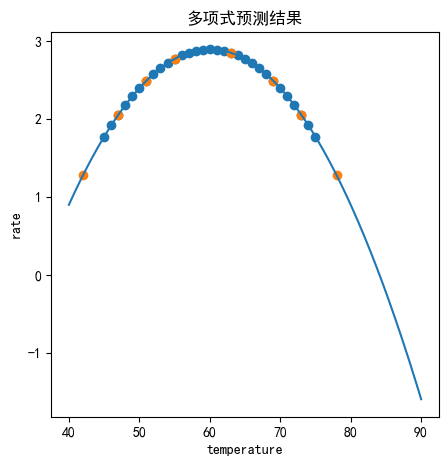

In [50]:
x_2_range=np.linspace(40,90,300).reshape(-1,1)
x_2_range=poly2.transform(x_2_range)
y_2_range_predict=lr2.predict(x_2_range)

fig3=plt.figure(figsize=(5,5))
plt.plot(x_range,y_2_range_predict)
plt.scatter(x_train,y_train)
plt.scatter(x_test,y_test)

plt.title('多项式预测结果（2）')
plt.xlabel('temperature')
plt.ylabel('rate')
plt.show()

 r2_5_train 0.9999999999999997 
 r2_5_test 0.9999999999999977


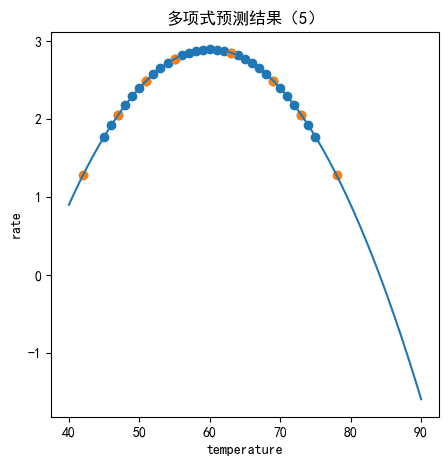

In [53]:
poly5=PolynomialFeatures(degree=5)
x_5_train=poly5.fit_transform(x_train)
x_5_test=poly5.transform(x_test)
lr3=LinearRegression()
lr3.fit(x_5_train,y_train)

y_5_train_predict=lr3.predict(x_5_train)
y_5_test_predict=lr3.predict(x_5_test)
r2_5_train=r2_score(y_train,y_5_train_predict)
r2_5_test=r2_score(y_test,y_5_test_predict)
print(' r2_5_train',r2_5_train,'\n','r2_5_test',r2_5_test)

x_5_range=np.linspace(40,90,300).reshape(-1,1)
x_5_range=poly5.transform(x_5_range)
y_5_range_predict=lr3.predict(x_5_range)

fig4=plt.figure(figsize=(5,5))
plt.plot(x_range,y_5_range_predict)
plt.scatter(x_train,y_train)
plt.scatter(x_test,y_test)

plt.title('多项式预测结果（5）')
plt.xlabel('temperature')
plt.ylabel('rate')
plt.show()